### Data Understanding and Basic Cleaning

Before we can engineer great features, we need to understand what we're working with and fix the problems that raw data always has. Real data is never clean, it has missing values, duplicate rows, outliers, and categories recorded inconsistently. Trying to build a model on top of these problems is like building a house on a shaky foundation.

**In this notebook we will cover:**
1. How to profile and explore raw features before touching them
2. Types of missing data and how to handle each type
3. Detecting and handling outliers
4. Fixing data quality issues like duplicates and inconsistent categories

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
print('Libraries loaded!')

Libraries loaded!


In [3]:
# Create a synthetic customer dataset with intentional problems
n = 300
np.random.seed(42)

df = pd.DataFrame({
    'customer_id':       range(1001, 1001 + n),
    'age':               np.random.randint(18, 70, n).astype(float),
    'salary':            np.random.lognormal(10.5, 0.8, n),   # skewed
    'city':              np.random.choice(['New York', 'NY', 'new_york', 'Berlin', 'berlin', 'Paris'], n),
    'gender':            np.random.choice(['Male', 'Female', None], n, p=[0.48, 0.48, 0.04]),
    'purchase_amount':   np.random.exponential(150, n),
    'product_category':  np.random.choice(['Electronics', 'Clothing', 'Food', 'Books'], n),
    'churn':             np.random.binomial(1, 0.3, n),
})

In [5]:
# Introduce missing values
df.loc[np.random.choice(n, 40, replace=False), 'age']    = np.nan   # 13% missing
df.loc[np.random.choice(n, 70, replace=False), 'salary'] = np.nan   # 23% missing
df.loc[np.random.choice(n, 20, replace=False), 'city']   = np.nan

In [7]:
# Introduce outliers in salary
df.loc[np.random.choice(n, 5, replace=False), 'salary'] = 2_000_000

In [9]:
# Add duplicate rows
duplicates = df.sample(10).copy()
df = pd.concat([df, duplicates], ignore_index=True)

In [11]:
print(f'Dataset shape: {df.shape}')

Dataset shape: (310, 8)


We've deliberately introduced problems into this dataset like, missing values in `age`, `salary`, and `city`, outlier salaries of $2,000,000, and 10 duplicate rows. This gives us a controlled environment to practise on. In real life, these problems arrive unannounced.

In [14]:
df.head()

,customer_id,age,salary,city,gender,purchase_amount,product_category,churn
0,1001,56.0,32287.766317,new_york,Male,434.334240,Electronics,0
1,1002,NaN,41961.104254,new_york,Female,94.498116,Electronics,0
2,1003,46.0,78578.111961,new_york,Female,142.559126,Food,0
3,1004,32.0,15492.868151,New York,Male,27.414358,Electronics,0
4,1005,60.0,39615.250617,new_york,Male,709.416703,Books,0


### Profiling the Raw Data First

The very first thing to do with any new dataset is look at it carefully before changing anything. You want to know: what types are the columns? How many missing values are there? What does the typical value look like? Are there any obvious red flags in the distributions?

Skipping this step and jumping straight into cleaning is one of the most common beginner mistakes. You'll fix the wrong things, or worse, fix something that didn't need fixing. `df.info()` and `df.describe()` together give you a quick but powerful first read of the data.

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       310 non-null    int64  
 1   age               269 non-null    float64
 2   salary            238 non-null    float64
 3   city              290 non-null    object 
 4   gender            300 non-null    object 
 5   purchase_amount   310 non-null    float64
 6   product_category  310 non-null    object 
 7   churn             310 non-null    int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 19.5+ KB


In [19]:
df.describe()

,customer_id,age,salary,purchase_amount,churn
count,310.000000,269.000000,2.380000e+02,310.000000,310.000000
mean,1152.716129,42.996283,8.973149e+04,158.668385,0.277419
std,87.458710,14.817169,2.845109e+05,157.620689,0.448449
min,1001.000000,18.000000,2.461986e+03,0.960952,0.000000
25%,1077.250000,31.000000,1.979641e+04,39.384122,0.000000
50%,1154.500000,43.000000,3.412873e+04,113.802810,0.000000
75%,1228.750000,56.000000,6.709738e+04,219.215822,1.000000
max,1300.000000,69.000000,2.000000e+06,877.729314,1.000000


In [21]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_report = pd.DataFrame({'missing_count': missing, 'missing%': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing%', ascending=False)
print('Missing Value Report:')
missing_report

Missing Value Report:


,missing_count,missing%
salary,72,23.2
age,41,13.2
city,20,6.5
gender,10,3.2


Four columns have missing values. `salary` is the worst at 23% & `gender` is only 3.2% missing. This matters because different levels of missingness call for different strategies: a column that's 23% missing needs more careful thought than one that's 3% missing.

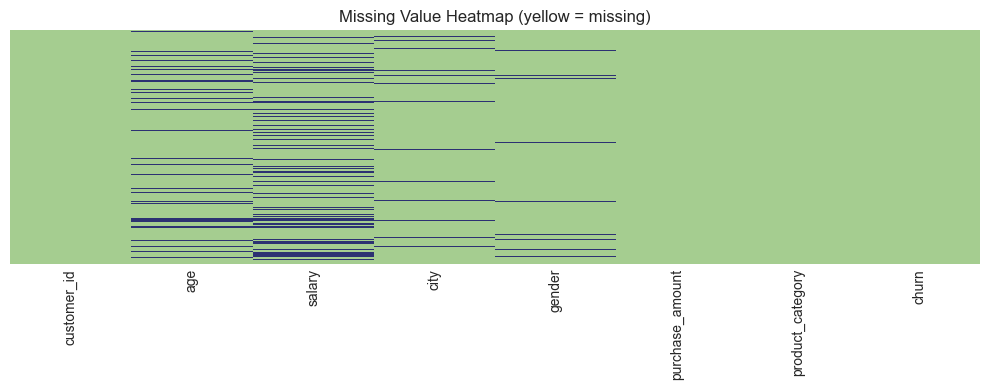

In [24]:
# Visual heatmap of missingness
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='crest', ax=ax)
ax.set_title('Missing Value Heatmap (yellow = missing)')
plt.tight_layout()
plt.show()

### Handling Missing Values

Not all missing data is the same and treating every missing value the same way is a common mistake that introduces bias.

Imagine a dataset of hospital patients where `blood_pressure` is sometimes missing. If it's missing because the nurse forgot to record it on busy days (random chance), that's very different from it being missing because patients with dangerously high pressure refused to be measured (missing for a reason).

There are three main types of missingness:

**MCAR(Missing Completely at Random)**: The missing values have no relationship to anything else in the dataset. Think of a sensor that randomly drops out. It's safe to drop these rows or fill with simple statistics, because the missingness is genuinely random and won't bias our data.

**MAR(Missing at Random)**: Missing at Random might be the most complex of the missing data types. If the likelihood of missingness is different for different groups, but equally likely within a group, then that data is missing at random. It’s kind of a hybrid of missing for a reason and missing completely at random. Ex : several scientific studies have shown that individuals do not like to report their weight, especially when they have a Body Mass Index (BMI) outside of the “normal” range. This is an example of Missing at Random data because we can assume that some groups are not reporting their weight for a reason, but that anyone within that group (i.e., someone with a non-“normal” BMI) has an equal probability of not reporting their weight.

**MNAR(Missing Not at Random)**: The missingness depends on the missing value itself. High earners tend not to report their salary. This is the most dangerous type — no statistical fix exists. The best approach is to add a binary flag column (`salary_was_missing`) so the model can at least know that the value was missing, even if we have to fill it with something.

Here's a quick decision guide:

| Situation | Strategy |
|---|---|
| Column is >50% missing | Drop the column |
| Row has >50% missing columns | Drop the row |
| Numeric, MCAR, roughly symmetric | Mean imputation |
| Numeric, skewed or has outliers | Median imputation |
| Categorical | Mode or 'Unknown' constant |
| MAR, multiple columns are informative | KNN or Iterative imputer |

In [27]:
df_work = df.copy()

In [29]:
# Strategy 1: Drop rows where more than 50% of values are null
threshold = len(df_work.columns) * 0.5
before = len(df_work)

df_work = df_work[df_work.isnull().sum(axis=1) <= threshold]

print(f'Strategy 1 - Drop rows with >50% nulls: {before} → {len(df_work)} rows')

Strategy 1 - Drop rows with >50% nulls: 310 → 310 rows


In [31]:
# Strategy 2: Mean imputation (good for balanced numeric data)
df_mean = df_work.copy()
age_mean = df_mean['age'].mean()
df_mean['age'] = df_mean['age'].fillna(age_mean)

print(f'Mean imputation for age: filled NaNs with {age_mean:.1f}')

Mean imputation for age: filled NaNs with 43.0


In [33]:
# Strategy 3: Median imputation (better for skewed data like salary)
df_median = df_work.copy()
salary_median = df_median['salary'].median()
df_median['salary'] = df_median['salary'].fillna(salary_median)

print(f'Median imputation for salary: filled NaNs with {salary_median:.0f}')

Median imputation for salary: filled NaNs with 34129


In [35]:
# Strategy 4: Mode imputation (categorical)
df_mode = df_work.copy()
city_mode = df_mode['city'].mode()[0]
df_mode['city'] = df_mode['city'].fillna(city_mode)

print(f'Mode imputation for city: filled NaNs with "{city_mode}"')

Mode imputation for city: filled NaNs with "new_york"


In [37]:
# Strategy 5: Constant imputation
df_const = df_work.copy()
df_const['city']   = df_const['city'].fillna('Unknown')
df_const['gender'] = df_const['gender'].fillna('Unknown')

print('Constant imputation: city and gender filled with "Unknown"')

Constant imputation: city and gender filled with "Unknown"


### **Using sklearn imputation methods**

In [40]:
# sklearn imputers work on numeric arrays
numeric_cols = ['age', 'salary', 'purchase_amount']
X_num = df_work[numeric_cols].values

#### **1. SimpleImputer**

`SimpleImputer(strategy='mean')` is a mean imputation technique, it replaces every missing (NaN) value in a column with that column's arithmetic mean, computed from all non-missing values. It is part of scikit-learn's preprocessing pipeline and follows the standard fit → transform pattern.

In [43]:
# Strategy 6: SimpleImputer (mean)
simple_imp = SimpleImputer(strategy='mean')
X_simple = simple_imp.fit_transform(X_num)

print(f'SimpleImputer: {np.isnan(X_num).sum()} NaNs → {np.isnan(X_simple).sum()} NaNs')

SimpleImputer: 113 NaNs → 0 NaNs


How `fit_transform` Works:

- **fit(X_num)** : Scans each numeric column, ignores NaNs, and computes and stores the column mean. Nothing is changed in the data at this stage.

- **transform(X_num)** : Uses the stored means to fill every NaN position. Returns a new array X_simple with zero missing values.

- **fit_transform(X_num)** : Does both steps in a single call, which is what your code uses.

A critical rule in production: you always call `fit` only on training data, then `transform` on test data separately. This prevents data leakage, where test set statistics bleed into training.

**When to Prefer Other Strategies:**

- Mean imputation is not always the best choice. It reduces variance and distorts correlations between features since all missing entries get the same value:

- Use `strategy='median'` when the column has outliers, since the median is more robust to skew

- Use `strategy='most_frequent'` for categorical or ordinal data

- Use `strategy='constant'` when the missingness itself is meaningful (e.g., filling with 0 or "Unknown")

#### **2. KNNImputer**

KNNImputer is a `multivariate` imputation method where instead of filling a missing value with a single value computed from one column alone, it looks at the entire row profile of a data point and finds the most similar rows to estimate the missing value.

**Core Intuition** : If two rows are similar across all their known features, it is reasonable to assume their unknown (missing) values would also be similar. For example, in a medical dataset, two patients of the same age, weight, and BMI are likely to have similar blood pressure — so one's known blood pressure can help estimate the other's missing one.

This is fundamentally different from `SimpleImputer(strategy='mean')`, which is univariate and it only uses values within a single column and completely ignores relationships between features.

In [48]:
# Strategy 7: KNN Imputer (uses similar rows to fill missing)
knn_imp = KNNImputer(n_neighbors=5)
X_knn = knn_imp.fit_transform(X_num)

print(f'KNNImputer: {np.isnan(X_num).sum()} NaNs → {np.isnan(X_knn).sum()} NaNs')

KNNImputer: 113 NaNs → 0 NaNs


Research shows that when more than 20% of data is missing, KNN imputation significantly outperforms mean/median in terms of prediction MSE. It is especially powerful when features are correlated.

KNNImputer is computationally expensive at scale because it computes pairwise distances across all rows for each missing value. For large datasets (millions of rows), this can be slow. 

Always normalize/scale your features before using it, since unscaled features (e.g., age in range 0–100 vs. salary in range 0–100,000) would cause distance calculations to be dominated by the high-magnitude feature.

#### **3. IterativeImputer**

`IterativeImputer` is the most sophisticated of the three strategies where it treats imputation as a **regression problem**, modeling the features with missing values as a function of all other features. It is scikit-learn's implementation of the well-known statistical algorithm called **MICE (Multiple Imputation by Chained Equations)**.

**IterativeImputer** asks: `"Can I train a model to predict what this missing value should be, using all the other columns as input features?"`. This turns the imputation problem into a series of supervised regression tasks, one for each column that has missing data.

In [52]:
# Strategy 8: Iterative Imputer (models each feature as function of others)
iter_imp = IterativeImputer(random_state=42, max_iter=10)
X_iter = iter_imp.fit_transform(X_num)

print(f'IterativeImputer: {np.isnan(X_num).sum()} NaNs → {np.isnan(X_iter).sum()} NaNs')

IterativeImputer: 113 NaNs → 0 NaNs


In [54]:
print('KNN and Iterative imputers are more accurate but slower. Use them for MAR data.')

KNN and Iterative imputers are more accurate but slower. Use them for MAR data.


All three sklearn imputers produce zero NaNs — they all fill every missing value. The difference is *how*: SimpleImputer uses a fixed statistic (mean), KNNImputer finds the k most similar rows and averages their values, and IterativeImputer models each feature as a function of the others. KNN and Iterative are more accurate but meaningfully slower on large datasets. For quick prototyping, SimpleImputer is usually fine.

### Handling Outliers

An outlier is a value that sits far away from the rest of the data. In our salary column, someone recorded $2,000,000 that's almost certainly a data entry error, not a real customer.

Outliers aren't always bad. Sometimes they're genuine extreme values that your model should know about. But they can cause serious problems. Linear models get pulled towards extreme values because they minimise squared error and one $2M salary will pull the regression line far away from where most of the data lives. Distance-based models like KNN measure distances that get distorted when one column's range is much larger than others. Tree-based models (Random Forest, XGBoost) are much less sensitive because they split on thresholds, not distances.

The two most reliable ways to detect outliers are the **z-score method** (flag values more than 3 standard deviations from the mean) and the **IQR method** (flag values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR). The IQR method is more robust for skewed data because it uses the median, not the mean.

Once detected, you have three choices: remove the outlier if it's clearly a data error, **cap it** (clip to the 5th–95th percentile) to keep the row while limiting its influence, or **log-transform** the column to naturally compress extreme values.

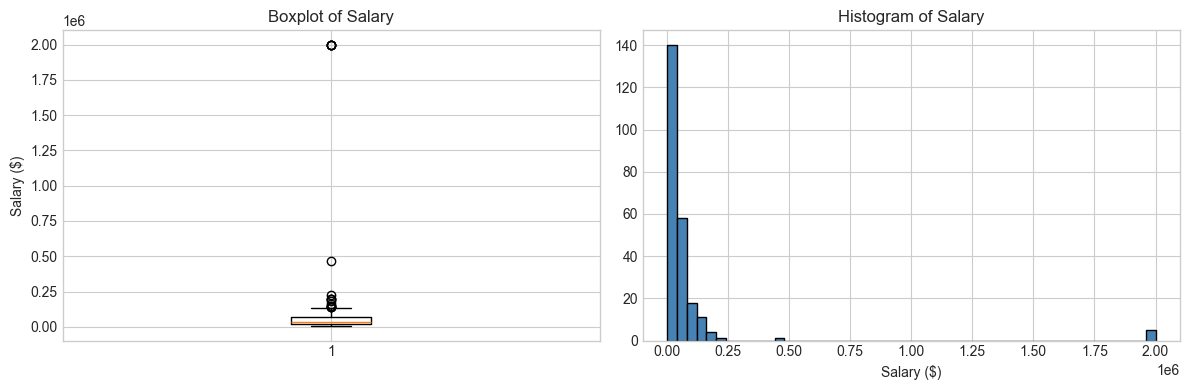

Max salary: 2,000,000 - suspicious outlier!


In [58]:
salary_clean = df_work['salary'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(salary_clean)
axes[0].set_title('Boxplot of Salary')
axes[0].set_ylabel('Salary ($)')

axes[1].hist(salary_clean, bins=50, edgecolor='black', color='steelblue')
axes[1].set_title('Histogram of Salary')
axes[1].set_xlabel('Salary ($)')

plt.tight_layout()
plt.show()
print(f'Max salary: {salary_clean.max():,.0f} - suspicious outlier!')

In [60]:
df_out = df_work.copy()

salary = df_out['salary'].dropna()

#### **Z-score Method**

The Z-score of any datapoint tells us how far away the datapoint is from the average of that column. The points which have z-score more than 3 are the datapoints more than 3 standard deviations away from the mean and we consider those as outliers and remove them.

In [63]:
# Z-score method
z_scores = np.abs(stats.zscore(salary))
outliers_z = salary[z_scores > 3]

print(f'Z-score method: {len(outliers_z)} outliers (|z| > 3)')
print(outliers_z.values)

Z-score method: 5 outliers (|z| > 3)
[2000000. 2000000. 2000000. 2000000. 2000000.]


#### **IQR Method**:

The IQR method builds a "fence" around your data using the middle 50% spread, and anything outside that fence is flagged as an outlier. Here is the full process in 4 steps:

`Step 1: Compute the Quartiles and IQR`
 - Split your sorted data into four equal parts.
 - Q1 = 25th percentile (value below which 25% of data falls)
 - Q3 = 75th percentile (value below which 75% of data falls)
 - IQR = Q3 − Q1 → the spread of the middle 50% of your data

`Step 2: Build the Fence`
 - **Lower bound** = Q1−1.5×IQR
 - **Upper bound** = Q3+1.5×IQR

`Step 3: Detect Outliers`
Any value below the lower bound or above the upper bound is an outlier.

`Step 4: Remove or Cap Them`

- Once detected, you have two choices:
    - **Drop (Removal/Trimming)** : Delete the rows entirely. Use when outliers are data errors or noise.
    - **Cap (Winsorizing)** : Replace outliers with the boundary value instead of deleting. Use when you want to retain the row but neutralize the extreme value.

In [66]:
# IQR method
Q1, Q3 = salary.quantile(0.25), salary.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers_iqr = salary[(salary < lower) | (salary > upper)]

print(f'IQR method: {len(outliers_iqr)} outliers (outside [{lower:.0f}, {upper:.0f}])')

IQR method: 17 outliers (outside [-51155, 138049])


In [68]:
# Strategy 1: Capping / Winsorizing at 5th and 95th percentile
p5  = df_out['salary'].quantile(0.05)
p95 = df_out['salary'].quantile(0.95)

df_out['salary_capped'] = df_out['salary'].clip(lower=p5, upper=p95)

In [70]:
# Strategy 2: Log transform
df_out['salary_log'] = np.log1p(df_out['salary'])  # log1p = log(1 + x), safe for 0

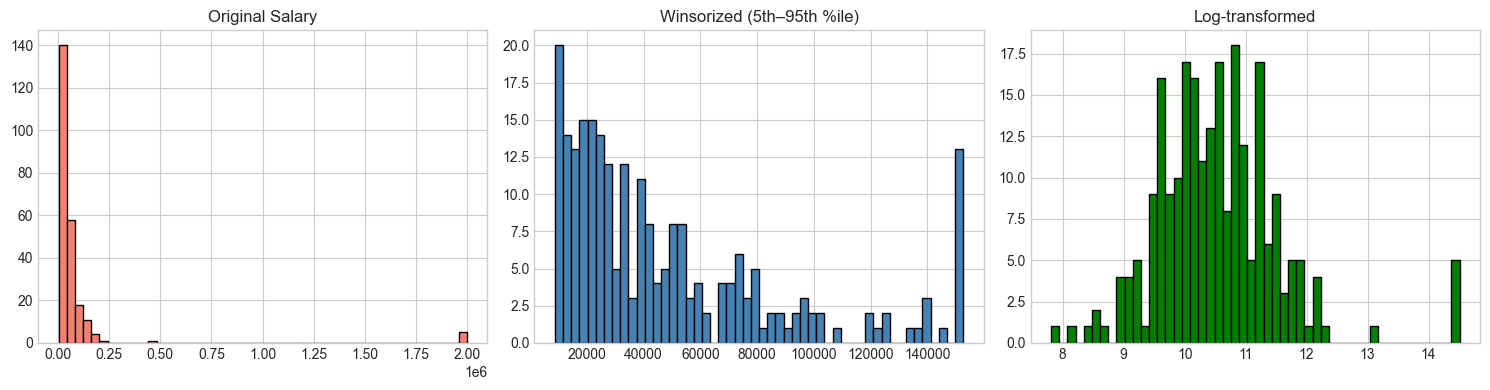

In [72]:
# Compare distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_out['salary'].dropna().hist(bins=50, ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('Original Salary')

df_out['salary_capped'].dropna().hist(bins=50, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Winsorized (5th–95th %ile)')

df_out['salary_log'].dropna().hist(bins=50, ax=axes[2], color='green', edgecolor='black')
axes[2].set_title('Log-transformed')

plt.tight_layout()
plt.show()

Look at the three histograms where the original salary distribution has a long right tail and those $2M values are barely visible but they're dragging the mean far to the right. After winsorizing (clipping at the 5th and 95th percentile), the extreme tail is gone. After log-transforming, the whole distribution is more bell-shaped and symmetric. The log transform is the most elegant solution when the underlying data is genuinely log-normally distributed, which salary data typically is.

### Basic Data Quality Fixes

Missing values and outliers are the most famous data problems, but real datasets have other issues that are just as damaging and easier to overlook.

**Duplicate rows** sound harmless but they quietly distort your model. If a row appears twice in your training data, the model will treat that observation as twice as important as it actually is. On a large dataset this can bias coefficients, distort class balances, and make evaluation metrics look better than they are.

**Inconsistent categories** are a silent killer. If your city column has 'NY', 'New York', and 'new_york', your model sees three completely different cities. It will compute separate statistics for each. One-hot encoding will create three separate columns. All of that from what is actually a single city. Lowercasing and stripping whitespace followed by a manual mapping dictionary solves this reliably.

**Wrong data types** such as a number stored as a string will cause pandas to silently skip that column in any numeric operation. `df.info()` always shows you the dtypes, so make it part of your profiling habit.

In [76]:
df_qc = df.copy()

# --- Deduplication ---
print(f'Rows before dedup: {len(df_qc)}')
print(f'Duplicate rows found: {df_qc.duplicated().sum()}')

df_qc = df_qc.drop_duplicates()
print(f'Rows after dedup:  {len(df_qc)}')

Rows before dedup: 310
Duplicate rows found: 10
Rows after dedup:  300


In [78]:
# --- Fix inconsistent city names ---
print('City value counts BEFORE fixing:')
print(df_qc['city'].value_counts())

# Step 1: lowercase and strip whitespace
df_qc['city'] = df_qc['city'].str.lower().str.strip()

# Step 2: map known variations to canonical names
city_map = {
    'new york': 'New York',
    'ny':       'New York',
    'new_york': 'New York',
    'berlin':   'Berlin',
    'paris':    'Paris',
}
df_qc['city'] = df_qc['city'].map(city_map).fillna(df_qc['city'])

print('\nCity value counts AFTER fixing:')
print(df_qc['city'].value_counts())

City value counts BEFORE fixing:
city
new_york    52
Paris       52
New York    47
berlin      46
Berlin      43
NY          40
Name: count, dtype: int64

City value counts AFTER fixing:
city
New York    139
Berlin       89
Paris        52
Name: count, dtype: int64


Before the fix, 'New York', 'NY', and 'new_york' were three separate categories. After lowercasing, stripping, and applying the mapping dictionary, they're all 'New York'. The value counts now show three clean city names instead of six messy ones. This kind of manual mapping takes a few minutes but saves hours of debugging downstream.

In [81]:
# --- Fix wrong data types ---
# Simulate a numeric column stored as string (common from CSV imports)
df_qc['purchase_amount_str'] = df_qc['purchase_amount'].astype(str)

print(f'purchase_amount_str dtype: {df_qc["purchase_amount_str"].dtype}')

# Can't do math on strings!
try:
    df_qc['purchase_amount_str'].mean()
except TypeError as e:
    print(f'Error: {e}')

# Fix: convert to numeric (pd.to_numeric handles errors gracefully)
df_qc['purchase_amount_fixed'] = pd.to_numeric(df_qc['purchase_amount_str'], errors='coerce')
print(f'\nAfter fix dtype: {df_qc["purchase_amount_fixed"].dtype}')
print(f'Mean purchase amount: {df_qc["purchase_amount_fixed"].mean():.2f}')

purchase_amount_str dtype: object
Error: Could not convert string '434.3342404681248594.49811646520885142.559125886465527.414358388519783709.416702913921939.530724752652496429.0013997240832157.321958920284140.3733334308291107.8277628888661839.3352542077943929.13386550350509237.36273479307601530.950019533182527226.8361136359194764.646346160961168.937451249915272521.5626324790162322.84814550390007394.14818307101314792.00746535745628.65505448642779775.68727823408211212.97052132219062178.619310363200625.066932719026028253.7869504479472838.1256000860879438.00516309544646115.49594764362556134.81917862803783130.155876829420114.391885445652061314.898721693713546.3052246500523320.80569914541005329.393714772005467.3514529129919297.21401767124433248.72812046004185159.736875179793120.0622172354848113.6507345128526278.7521749865397369.9468117945924245.11586352144267192.78833699956027102.7398725876480412.67791708533378237.30443917706247172.4505191395873611.877726029236847285.7797934566307102.5230566

### <font color='green'>Key things to remember from this notebook</font>

Always profile your data first — `df.info()` and `df.describe()` before touching anything. Missing data is not all the same: MCAR is safe to drop or fill simply, MAR benefits from model-based imputation, and MNAR requires a flag column. Outliers can be removed, capped, or transformed depending on whether they're errors or genuine extreme values. And never underestimate the damage that inconsistent category labels and wrong data types can do.

In the next notebook we go deeper into numeric features specifically — scaling, handling skewed distributions, binning, and creating polynomial features.